In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight


In [2]:
# Dataset and training parameters
DATASET_DIR = "../data/images"

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 20        # Baseline training only
NUM_CLASSES = 6  # cardboard, glass, metal, paper, plastic, trash


In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

train_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

val_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)

print(train_generator.class_indices)


Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.
{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


In [4]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights_dict = dict(enumerate(class_weights))
print(class_weights_dict)


{0: 1.04437564499484, 1: 0.8412302576891105, 2: 1.0284552845528456, 3: 0.7086834733893558, 4: 0.8739205526770294, 5: 3.066666666666667}


In [5]:
base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze most layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)

# Add regularization
x = Dense(256, activation="relu", kernel_regularizer=l2(0.0001))(x)
x = Dropout(0.3)(x)

output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 zero_padding2d (ZeroPadding2D)  (None, 230, 230, 3)  0          ['input_1[0][0]']                
                                                                                                  
 conv1/conv (Conv2D)            (None, 112, 112, 64  9408        ['zero_padding2d[0][0]']         
                                )                                                                 
                                                                                              

In [6]:
model.compile(
    optimizer=Adam(learning_rate=3e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [7]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6
)


In [8]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights_dict
)


Epoch 1/20
127/127 [==============================] - 270s 2s/step - loss: 1.8429 - accuracy: 0.3182 - val_loss: 1.4025 - val_accuracy: 0.4891 - lr: 3.0000e-05
Epoch 2/20
127/127 [==============================] - 265s 2s/step - loss: 1.3788 - accuracy: 0.4995 - val_loss: 1.1488 - val_accuracy: 0.6064 - lr: 3.0000e-05
Epoch 3/20
127/127 [==============================] - 261s 2s/step - loss: 1.1394 - accuracy: 0.5949 - val_loss: 1.0183 - val_accuracy: 0.6282 - lr: 3.0000e-05
Epoch 4/20
127/127 [==============================] - 260s 2s/step - loss: 1.0167 - accuracy: 0.6413 - val_loss: 0.9252 - val_accuracy: 0.6620 - lr: 3.0000e-05
Epoch 5/20
127/127 [==============================] - 268s 2s/step - loss: 0.9147 - accuracy: 0.6833 - val_loss: 0.8498 - val_accuracy: 0.7197 - lr: 3.0000e-05
Epoch 6/20
127/127 [==============================] - 265s 2s/step - loss: 0.8292 - accuracy: 0.7189 - val_loss: 0.8149 - val_accuracy: 0.7137 - lr: 3.0000e-05
Epoch 7/20
127/127 [====================

In [9]:
os.makedirs("../models", exist_ok=True)
model.save("../models/densenet121_regularized.h5")
print("Regularized DenseNet121 model saved.")


Regularized DenseNet121 model saved.


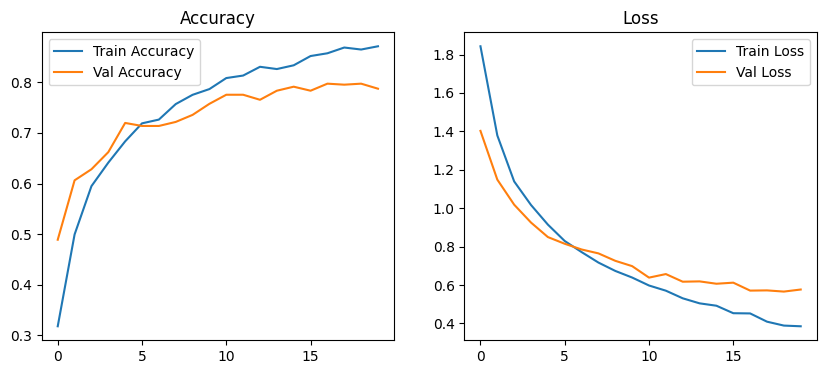

In [10]:
plt.figure(figsize=(10,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.legend()
plt.title("Accuracy")

# Loss
plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss")

plt.show()


In [11]:
# Unfreeze last 30 layers only
for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True

# Recompile with lower learning rate
model.compile(
    optimizer=Adam(learning_rate=3e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

FINE_TUNE_EPOCHS = 15

history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights_dict
)


Epoch 1/15
127/127 [==============================] - 328s 2s/step - loss: 0.3638 - accuracy: 0.8799 - val_loss: 0.5573 - val_accuracy: 0.8151 - lr: 3.0000e-05
Epoch 2/15
127/127 [==============================] - 282s 2s/step - loss: 0.3627 - accuracy: 0.8780 - val_loss: 0.5332 - val_accuracy: 0.8250 - lr: 3.0000e-05
Epoch 3/15
127/127 [==============================] - 265s 2s/step - loss: 0.3254 - accuracy: 0.8972 - val_loss: 0.5420 - val_accuracy: 0.8211 - lr: 3.0000e-05
Epoch 4/15
127/127 [==============================] - 257s 2s/step - loss: 0.3220 - accuracy: 0.8943 - val_loss: 0.5116 - val_accuracy: 0.8310 - lr: 3.0000e-05
Epoch 5/15
127/127 [==============================] - 261s 2s/step - loss: 0.2926 - accuracy: 0.9022 - val_loss: 0.5298 - val_accuracy: 0.8012 - lr: 3.0000e-05
Epoch 6/15
127/127 [==============================] - 257s 2s/step - loss: 0.2702 - accuracy: 0.9111 - val_loss: 0.4994 - val_accuracy: 0.8390 - lr: 3.0000e-05
Epoch 7/15
127/127 [====================

In [12]:
model.save("../models/densenet121_final.h5")


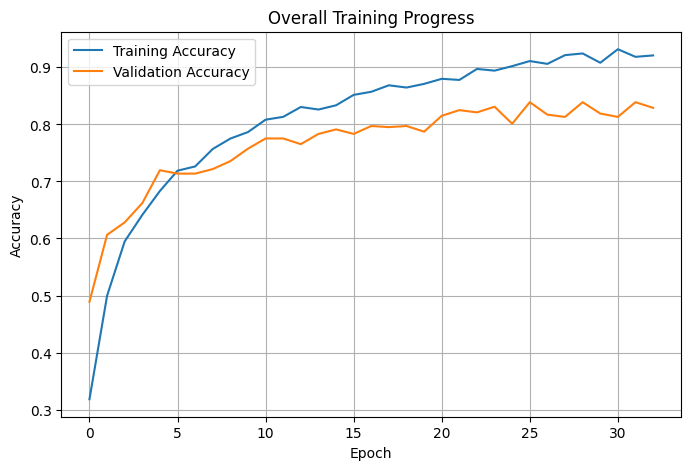

In [13]:
     plt.figure(figsize=(8,5))

# Combine histories
train_acc = history.history["accuracy"] + history_finetune.history["accuracy"]
val_acc = history.history["val_accuracy"] + history_finetune.history["val_accuracy"]

plt.plot(train_acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Overall Training Progress")
plt.legend()
plt.grid(True)

plt.show()


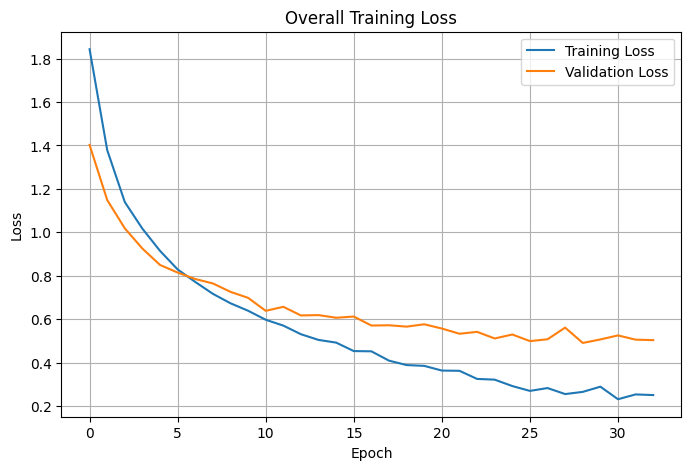

In [14]:
plt.figure(figsize=(8,5))

train_loss = history.history["loss"] + history_finetune.history["loss"]
val_loss = history.history["val_loss"] + history_finetune.history["val_loss"]

plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Overall Training Loss")
plt.legend()
plt.grid(True)

plt.show()
